# Exploratory Data Analysis (EDA)
---

## Load Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
customers = pd.read_csv("../data/processed/customers_clean.csv", parse_dates=["signup_date", "last_login_date"])
subscriptions = pd.read_csv("../data/processed/subscriptions_clean.csv", parse_dates=["start_date", "end_date"])
payments = pd.read_csv("../data/processed/payments_clean.csv", parse_dates=["payment_date"])
usage = pd.read_csv("../data/processed/product_usage_clean.csv", parse_dates=["usage_date"])
tickets = pd.read_csv("../data/processed/support_tickets_clean.csv", parse_dates=["created_date"])

## Build Analytic Dataset

In [3]:
# Aggregate Usage
usage_agg = (
    usage.groupby("customer_id").agg(
        avg_login = ("login_count", "mean"),
        total_login = ("login_count", "sum"),
        avg_session = ("session_duration", "mean"),
        feature_used = ("feature_used", "nunique")
    ).reset_index()
)

In [4]:
# Aggregate Tickets
ticket_agg = (
    tickets.groupby("customer_id").agg(
        ticket_count = ("ticket_id", "count"),
        avg_resolution=("resolution_time_hours", "mean")
    ).reset_index()
)

In [5]:
# Aggregate Payments
payment_agg = (
    payments.query("payment_status == 'Paid'").groupby("customer_id").agg(
        total_revenue = ("amount", "sum"),
        payment_count = ("payment_id", "count")
    ).reset_index()
)

In [6]:
# Master Analytics Dataset
analytics_df = (
    customers
    .merge(subscriptions, on="customer_id")
    .merge(usage_agg, on="customer_id", how="left")
    .merge(ticket_agg, on="customer_id", how="left")
    .merge(payment_agg, on="customer_id", how="left")
)

In [7]:
# Churned df 
churned_df = analytics_df[analytics_df["status"] == "Churned"]

## Missing Value Handling

In [8]:
cols = [
    "avg_login",
    "total_login",
    "avg_session",
    "feature_used",
    "ticket_count",
    "avg_resolution",
    "total_revenue",
    "payment_count"
]

analytics_df[cols] = analytics_df[cols].fillna(0)

## Baseline Churn & Segment Analysis

In [9]:
# Jumlah total customer unik
total_customers = analytics_df['customer_id'].nunique()

# Distribusi Active vs Churned
status_distribution = analytics_df['status'].value_counts()
status_percentage = analytics_df['status'].value_counts(normalize=True) * 100

print(f"Total Customer: {total_customers}")
print("\nDistribusi Status Customer (Jumlah):")
print(status_distribution)
print("\nDistribusi Status Customer (Persentase):")
print(status_percentage)

Total Customer: 20000

Distribusi Status Customer (Jumlah):
status
Active     14953
Churned     5047
Name: count, dtype: int64

Distribusi Status Customer (Persentase):
status
Active     74.765
Churned    25.235
Name: proportion, dtype: float64


In [10]:
# Churn Rate
churn_rate = (
    analytics_df['status']
    .eq('Churned')
    .mean()
    * 100
)

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 25.24%


In [11]:
# Churn by Plan
(
    pd.crosstab(
        analytics_df['plan'],
        analytics_df['status'],
        normalize='index'
    ) * 100
)

status,Active,Churned
plan,,
Basic,57.658888,42.341112
Enterprise,88.677303,11.322697
Premium,85.815424,14.184576
Standard,85.858419,14.141581


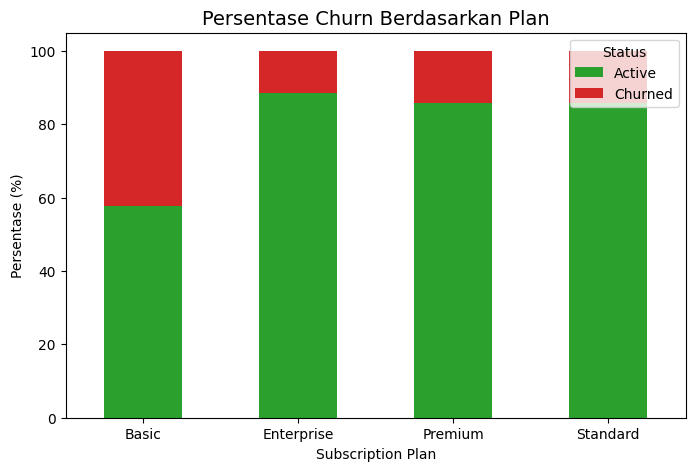

In [12]:
import matplotlib.pyplot as plt

plan_churn = pd.crosstab(analytics_df["plan"], analytics_df["status"], normalize="index") * 100

plan_churn.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(8, 5))
plt.title('Persentase Churn Berdasarkan Plan', fontsize=14)
plt.ylabel('Persentase (%)')
plt.xlabel('Subscription Plan')
plt.xticks(rotation=0)
plt.legend(title='Status', loc='upper right')
plt.show()

In [13]:
# Churn by Company Size
(
    pd.crosstab(
        analytics_df['company_size'],
        analytics_df['status'],
        normalize='index'
    ) * 100
)

status,Active,Churned
company_size,,
Large,82.247306,17.752694
Medium,81.200397,18.799603
Small,70.307423,29.692577


In [14]:
# Churn by Acquisiton Channel
(
    pd.crosstab(
        analytics_df['acquisition_channel'],
        analytics_df['status'],
        normalize='index'
    ) * 100
)

status,Active,Churned
acquisition_channel,,
Facebook Ads,74.886878,25.113122
Google Ads,75.757576,24.242424
LinkedIn,75.203666,24.796334
Organic,73.814788,26.185212
Referral,74.193548,25.806452


In [15]:
print("--- Rata-rata Login & Durasi Sesi Berdasarkan Status ---")
print(analytics_df.groupby("status")[["avg_login", "avg_session"]].mean())

--- Rata-rata Login & Durasi Sesi Berdasarkan Status ---
         avg_login  avg_session
status                         
Active    5.003599    45.016154
Churned   5.007287    44.908089


In [16]:
print("\n--- Rata-rata Jumlah Fitur yang Digunakan Berdasarkan Status ---")
print(analytics_df.groupby("status")["feature_used"].mean())


--- Rata-rata Jumlah Fitur yang Digunakan Berdasarkan Status ---
status
Active     4.726008
Churned    4.521894
Name: feature_used, dtype: float64


In [17]:
print("--- Performa Layanan Support Berdasarkan Status ---")
print(analytics_df.groupby("status")[["ticket_count", "avg_resolution"]].mean())

--- Performa Layanan Support Berdasarkan Status ---
         ticket_count  avg_resolution
status                               
Active       2.101852       21.109859
Churned      3.228651       22.685880


In [18]:
# Revenue Loss by plan
print("--- Revenue Loss Berdasarkan Plan ---")
print(churned_df.groupby("plan")["total_revenue"].sum())

--- Revenue Loss Berdasarkan Plan ---
plan
Basic         1728916.0
Enterprise    1191113.0
Premium       1189821.0
Standard       881001.0
Name: total_revenue, dtype: float64


In [19]:
# Revenue loss by Company size
print("--- Revenue Loss Berdasarkan Company Size ---")
print(churned_df.groupby("company_size")[
    "total_revenue"
].sum())

--- Revenue Loss Berdasarkan Company Size ---
company_size
Large      308644.0
Medium     922932.0
Small     3759275.0
Name: total_revenue, dtype: float64


In [20]:
# Tenure Analysis
analytics_df.groupby("status")[
    "tenure_months"
].mean()

status
Active     15.979603
Churned     9.988112
Name: tenure_months, dtype: float64

In [21]:
# Revenue Contribution (Dari customer yang masih Active)
active_revenue = analytics_df.query("status == 'Active'")["total_revenue"].sum()

# Revenue Loss (Dari customer yang Churned)
lost_revenue = analytics_df.query("status == 'Churned'")["total_revenue"].sum()

print(f"Total Revenue dari Customer Aktif : ${active_revenue:,.2f}")
print(f"Total Revenue yang Hilang (Loss)   : ${lost_revenue:,.2f}")

Total Revenue dari Customer Aktif : $36,398,589.00
Total Revenue yang Hilang (Loss)   : $4,990,851.00


In [22]:
# Correlation Matrix
num_cols = [
    "age",
    "monthly_fee",
    "tenure_months",
    "avg_login",
    "avg_session",
    "ticket_count",
    "total_revenue"
]

analytics_df[num_cols].corr()

,age,monthly_fee,tenure_months,avg_login,avg_session,ticket_count,total_revenue
age,1.000000,0.013407,-0.006517,0.001683,-0.013801,-0.003453,-0.003862
monthly_fee,0.013407,1.000000,0.113408,-0.007597,-0.000472,-0.167926,0.770001
tenure_months,-0.006517,0.113408,1.000000,-0.016680,0.006230,-0.157343,0.547858
avg_login,0.001683,-0.007597,-0.016680,1.000000,0.011773,-0.000270,-0.013620
avg_session,-0.013801,-0.000472,0.006230,0.011773,1.000000,0.003058,0.001380
ticket_count,-0.003453,-0.167926,-0.157343,-0.000270,0.003058,1.000000,-0.165342
total_revenue,-0.003862,0.770001,0.547858,-0.013620,0.001380,-0.165342,1.000000


In [23]:
# Create Churn Flag

analytics_df["churn_flag"] = (
    analytics_df["status"]
    == "Churned"
).astype(int)

corr_cols = num_cols + ["churn_flag"]

analytics_df[corr_cols].corr()

,age,monthly_fee,tenure_months,avg_login,avg_session,ticket_count,total_revenue,churn_flag
age,1.000000,0.013407,-0.006517,0.001683,-0.013801,-0.003453,-0.003862,-0.011523
monthly_fee,0.013407,1.000000,0.113408,-0.007597,-0.000472,-0.167926,0.770001,-0.194612
tenure_months,-0.006517,0.113408,1.000000,-0.016680,0.006230,-0.157343,0.547858,-0.263926
avg_login,0.001683,-0.007597,-0.016680,1.000000,0.011773,-0.000270,-0.013620,0.002602
avg_session,-0.013801,-0.000472,0.006230,0.011773,1.000000,0.003058,0.001380,-0.011439
ticket_count,-0.003453,-0.167926,-0.157343,-0.000270,0.003058,1.000000,-0.165342,0.302390
total_revenue,-0.003862,0.770001,0.547858,-0.013620,0.001380,-0.165342,1.000000,-0.228758
churn_flag,-0.011523,-0.194612,-0.263926,0.002602,-0.011439,0.302390,-0.228758,1.000000


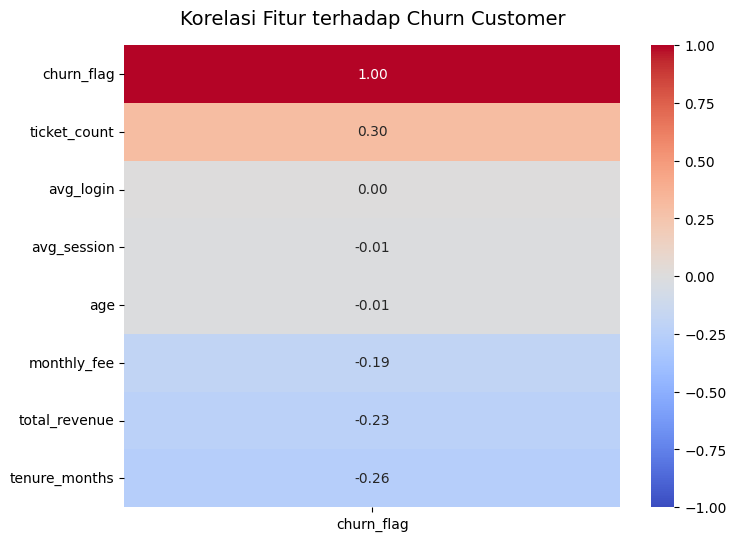

In [24]:
import seaborn as sns
plt.figure(figsize=(8, 6))
churn_corr = analytics_df[corr_cols].corr()[['churn_flag']].sort_values(by='churn_flag', ascending=False)

sns.heatmap(churn_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Korelasi Fitur terhadap Churn Customer', fontsize=14, pad=15)
plt.show()